## pypacity

### Examples of calculation

author: Mario Mañana 
last update: 3/2/2024

In [1]:
import sys
print( sys.version)
print(sys.path)

3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]
['c:\\Users\\mananam\\AppData\\Local\\anaconda3\\python312.zip', 'c:\\Users\\mananam\\AppData\\Local\\anaconda3\\DLLs', 'c:\\Users\\mananam\\AppData\\Local\\anaconda3\\Lib', 'c:\\Users\\mananam\\AppData\\Local\\anaconda3', '', 'C:\\Users\\mananam\\AppData\\Roaming\\Python\\Python312\\site-packages', 'C:\\Users\\mananam\\AppData\\Roaming\\Python\\Python312\\site-packages\\win32', 'C:\\Users\\mananam\\AppData\\Roaming\\Python\\Python312\\site-packages\\win32\\lib', 'C:\\Users\\mananam\\AppData\\Roaming\\Python\\Python312\\site-packages\\Pythonwin', 'c:\\Users\\mananam\\AppData\\Local\\anaconda3\\Lib\\site-packages', 'c:\\Users\\mananam\\AppData\\Local\\anaconda3\\Lib\\site-packages\\win32', 'c:\\Users\\mananam\\AppData\\Local\\anaconda3\\Lib\\site-packages\\win32\\lib', 'c:\\Users\\mananam\\AppData\\Local\\anaconda3\\Lib\\site-packages\\Pythonwin']


In [2]:
from cable import cable
from case import case
from ieee738 import ieee738
from cigre601 import cigre601
from cigre207 import cigre207
from pvsystems import pvsystems
import matplotlib.pyplot as plt 


# Needed only during the development phase.
from importlib import reload
reload(  cable)
reload(  case)
reload( ieee738)
reload( cigre601)
reload( cigre207)
reload( pvsystems)

<module 'pvsystems.pvsystems' from 'e:\\mario\\python\\pypacity\\pvsystems\\pvsystems.py'>

In [3]:

NSELECT = 2 
Cable1 = cable.Cable()
c_db, error = Cable1.load_cable_db()
Cable1.set_cable( NSELECT, conductor = '400 mm2 DRAKE 26/7 ACSR')
Cable1.EMISS = 0.8
Cable1.ABSORP = 0.8

PV1 = pvsystems.PVSystems()
Case1 = case.Case()
Case1.demo( NSELECT)
# Ambient conditions
Case1.TAMB = 40.0
Case1.CDR_LAT_DEG = 30
Case1.ALBEDO = 0.1
Case1.beta = 0
Case1.CDR_ELEV = 0
Case1.TCDRPRELOAD = 100
#Case1.TCDRMAX = 150
#Case1.TCDR = 100.0
Case1.VWIND = 0.4
Case1.WINDANG_DEG = 60
Case1.Z1_DEG = 90
Case1.Ns = 1.0
Case1.SUN_TIME = 11
Case1.NDAY = PV1.DayOfYear( 10, 6) # 10th June
print("NDAY: " + str(Case1.NDAY))

NDAY: 161


In [4]:
c_db

,Cstring,D,d,TLO,THI,TCDRMAX,RLO,RHI,EMISS,ABSORP,HNH,HEATOUT,HEATCORE,TotalS
0,400 mm2 DRAKE 26/7 ACSR,28.12,4.44,25,75,100,0.07284,0.08689,0.5,0.5,3,1139.5,351.7,486.6
1,LA-180,17.50,2.50,5,85,100,0.21993,0.25197,0.5,0.5,2,379.81,128.16,NaN
2,LA-280,21.80,3.44,5,85,100,0.13384,0.15707,0.5,0.5,2,623.22,147.22,NaN


### IEEE 738

In [7]:
# IEEE 738
X1 = ieee738.IEEE738()
X1.Debug = 0
X1.set_cable( Cable1)
X1.set_case( Case1)
X1.Case1.SORM = 1

X1.ieee_738_2013()
X1.outputs()

#print("temp: ", X1.Case1.TCDRPRELOAD)
#print('current: ', X1.Case1.TR)



# Print results
if NSELECT == 3:
    plt.plot( X1.Case1.TIME, X1.Case1.ATCDR)
if NSELECT == 4:
    print('The conductor temperature goes from {ti} to {tf} in {tt} minutes with a current of {i}'.format(ti=X1.Case1.TCDRPRELOAD, tf=X1.Case1.TCDRMAX, tt=X1.Case1.TT, i=X1.Case1.XISTEP))


#



 
****************************************************************
*******************************************************************
IEEE 738
*******************************************************************
The angle between wind and conductor is =  0.0  DEG
INPUT -> Steady-state temperature:  100  ºC
OUTPUT -> Steady-state current:  935.805  A
Solar heating:   23.108  W/m
Radiation cooling:  39.078  W/m
Convection cooling:  66.274  W/m


### CIGRE TB601

In [8]:
X2 = cigre601.CIGRE601()
X2.Debug = 0
X2.set_cable( Cable1)
X2.set_case( Case1)
X2.cigre601()
X2.output()


 
 
*******************************************************************
*******************************************************************
CIGRE TB601 
*******************************************************************
The angle between wind and conductor is =  0.0  DEG
INPUT -> Steady-state temperature:  100  ºC
OUTPUT -> Steady-state current:  786.163  A
Solar heating:   23.108  W/m
Radiation cooling:  39.104  W/m
Convection cooling:  42.048  W/m


### CIGRE TB207

In [9]:
X3 = cigre207.CIGRE207()
X3.Debug = 0
X3.set_cable( Cable1)
X3.set_case( Case1)
X3.cigre207()
X3.output()

 
 
*******************************************************************
*******************************************************************
CIGRE TB207 
*******************************************************************
INPUT -> Steady-state temperature:  100  ºC
OUTPUT -> Steady-state current:  928.868  A
Solar heating:   15.941  W/m
Radiation cooling:  39.104  W/m
Convection cooling:  57.866  W/m


## Steady state conductor temperature

In [10]:
X1.Case1.NSELECT = 1
X1.Case1.XIPRELOAD = 1500.0
X1.ieee_738_2013()
X1.outputs()

 
****************************************************************
*******************************************************************
IEEE 738
*******************************************************************
The angle between wind and conductor is =  0.0  DEG
INPUT -> Steady-state current:  1500.0  A
OUTPUT -> Steady-state temperature:  180.153  ºC
Solar heating:   23.108  W/m
Radiation cooling:  130.418  W/m
Convection cooling:  154.66  W/m


In [13]:
X2.Case1.NSELECT = 1
X2.Debug = 0
X2.cigre601()
X2.output()

 
 
*******************************************************************
*******************************************************************
CIGRE TB601 
*******************************************************************
The angle between wind and conductor is =  0.0  DEG
INPUT -> Steady-state current:  1500.0  A
OUTPUT -> Steady-state temperature:  199.223  ºC
Solar heating:   23.108  W/m
Radiation cooling:  160.418  W/m
Convection cooling:  136.13  W/m


In [43]:
print(X2.Case1.XIPRELOAD)
print(X2.Case1.TCDRPRELOAD)

1500.0
199.22317058859107


## Transient

In [14]:
PV1 = pvsystems.PVSystems()
Case1 = case.Case()
NSELECT = 3
Case1.demo( NSELECT)
# Ambient conditions
Case1.TAMB = 40.0
Case1.CDR_LAT_DEG = 30
Case1.ALBEDO = 0.1
Case1.beta = 0
Case1.CDR_ELEV = 0
Case1.TCDRPRELOAD = 100
#Case1.TCDRMAX = 150
#Case1.TCDR = 100.0
Case1.WINDANG_DEG = 60
Case1.Z1_DEG = 90
Case1.Ns = 1.0
Case1.SUN_TIME = 11
Case1.NDAY = PV1.DayOfYear( 10, 6) # 10th June

 
****************************************************************
*******************************************************************
IEEE 738
*******************************************************************
The angle between wind and conductor is =  0.0  DEG
Solar heating:   23.108  W/m
Radiation cooling:  37.27  W/m
Convection cooling:  79.103  W/m


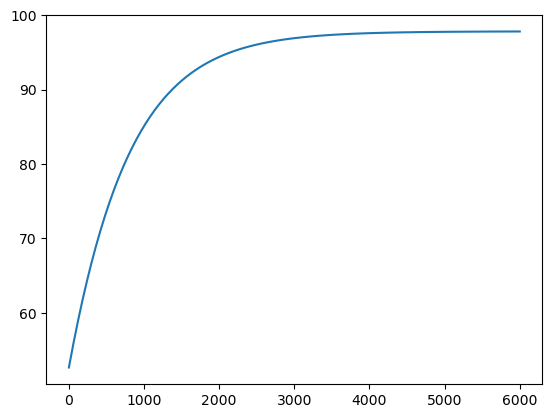

In [16]:
# IEEE 738
#X1 = ieee738.IEEE738()
X1.set_case( Case1)
X1.Debug = 0
#X1.set_cable( Cable1)
#X1.set_case( Case1)
X1.Case1.ATCDR = []
X1.Case1.TIME = []
X1.Case1.NSELECT = 3
X1.Case1.XIPRELOAD = 100
X1.Case1.XISTEP = 1000

X1.Case1.TT = 6000
X1.Case1.SORM = 1
X1.Case1.DELTIME = 60

X1.ieee_738_2013()
X1.outputs()



plt.plot( X1.Case1.TIME, X1.Case1.ATCDR)
ATCDRieee = X1.Case1.ATCDR
Time = X1.Case1.TIME

#

steps:  100
Tinitial:  61.80512892031013  ; dT:  0.01705843572596456
Tinitial:  61.822187356036096  ; dT:  3.906051599745549
Tinitial:  65.72823895578165  ; dT:  3.714806755283411
Tinitial:  69.44304571106505  ; dT:  3.5249568438162857
Tinitial:  72.96800255488134  ; dT:  3.337983341585361
Tinitial:  76.3059858964667  ; dT:  3.1550316399993816
Tinitial:  79.46101753646607  ; dT:  2.9769889153488402
Tinitial:  82.43800645181491  ; dT:  2.804535947356076
Tinitial:  85.24254239917099  ; dT:  2.638184258916096
Tinitial:  87.88072665808708  ; dT:  2.47830435817557
Tinitial:  90.35903101626265  ; dT:  2.3251482304122493
Tinitial:  92.6841792466749  ; dT:  2.1788678857291415
Tinitial:  94.86304713240405  ; dT:  2.0395310438323397
Tinitial:  96.90257817623639  ; dT:  1.9071346279634316
Tinitial:  98.80971280419982  ; dT:  1.781616501475631
Tinitial:  100.59132930567544  ; dT:  1.6628657382647292
Tinitial:  102.25419504394017  ; dT:  1.5507316321164242
Tinitial:  103.8049266760566  ; dT:  1.445

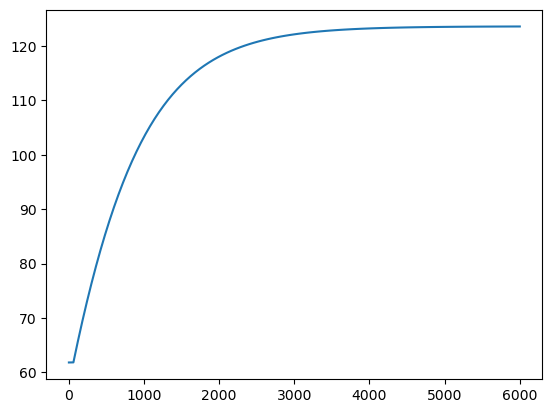

In [18]:
X2.Case1.NSELECT = 3
X2.Case1.XIPRELOAD = 100
X2.Case1.XISTEP = 1000
X2.Case1.TT = 100
X2.Case1.SORM = 1
X2.Case1.DELTIME = 60
X2.Case1.TIME = []
X2.Case1.ATCDR = []
X2.Debug = 0
X2.cigre601()
#X2.outputs()

plt.plot( X2.Case1.TIME, X2.Case1.ATCDR)
ATCDRcigre = X2.Case1.ATCDR 


In [47]:
#plt.plot( Time, ATCDRieee, Time, ATCDRcigre)

len(ATCDRcigre)

101